# **PORTFOLIO MANAGEMENT - MARKOWITZ AND OTHER VERSIONS**
## Prepared by Sepideh Maleki


In [ ]:
import warnings
warnings.filterwarnings("ignore")

### **Data preparation**
## Data preparation

In this notebook, I use ten large-cap US stocks from different sectors in order to build a simple empirical example of the mean--variance portfolio model.

- **Securities:** TSLA, WMT, BAC, GS, LLY, MRK, GOOG, META, AAPL, XOM.
- **Modeling period:** January 2019 to December 2024.
- **Backtesting period:** January 2025.
- **Frequency:** daily prices are downloaded first, and then daily returns are computed.

The aim is not to choose the best possible portfolio in practice, but to illustrate how the Markowitz model behaves with real financial data.

In [ ]:
#!pip install yfinance==0.2.12 # downgraded version
# !pip install --upgrade yfinance
# ---------------------------------------------
# Data preparation
# ---------------------------------------------

import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

In [ ]:
# We choose ten large-cap US stocks from different sectors.
tickers = ["TSLA", "WMT", "BAC", "GS", "LLY", "MRK", "GOOG", "META", "AAPL", "XOM"]

# Modeling period: used to estimate expected returns and covariance matrix
modeling_start = "2019-01-01"
modeling_end = "2024-12-31"

# Backtesting period: used to evaluate the portfolio after estimation
backtesting_start = "2025-01-01"
backtesting_end = "2025-01-31"

# Download daily adjusted close prices
modeling_prices = yf.download(
    tickers,
    start=modeling_start,
    end=modeling_end,
    interval="1d",
    auto_adjust=True
)["Close"]

backtesting_prices = yf.download(
    tickers,
    start=backtesting_start,
    end=backtesting_end,
    interval="1d",
    auto_adjust=True
)["Close"]

# Compute daily simple returns
r_modeling = modeling_prices.pct_change().dropna()
r_backtesting = backtesting_prices.pct_change().dropna()

# Display the first rows
r_modeling.head()



[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed


Ticker,AAPL,BAC,GOOG,GS,LLY,META,MRK,TSLA,WMT,XOM
Date,,,,,,,,,,
2019-01-03,-0.099607,-0.016026,-0.028484,-0.014649,-0.031076,-0.029039,-0.020505,-0.031472,-0.005142,-0.015354
2019-01-04,0.042690,0.041531,0.053786,0.032683,0.030096,0.047138,0.030119,0.057697,0.006246,0.036870
2019-01-07,-0.002227,-0.000782,-0.002167,0.005541,0.005407,0.000725,-0.011013,0.054361,0.011772,0.005200
2019-01-08,0.019064,-0.001956,0.007385,-0.003693,0.009195,0.032452,0.007424,0.001164,0.006981,0.007271
2019-01-09,0.016982,0.009800,-0.001505,0.006272,0.007478,0.011927,-0.007633,0.009483,-0.003256,0.005275


In [ ]:
r_modeling.head(3)

Ticker,AAPL,BAC,GOOG,GS,LLY,META,MRK,TSLA,WMT,XOM
Date,,,,,,,,,,
2019-01-03,-0.099607,-0.016026,-0.028484,-0.014649,-0.031076,-0.029039,-0.020505,-0.031472,-0.005142,-0.015354
2019-01-04,0.042690,0.041531,0.053786,0.032683,0.030096,0.047138,0.030119,0.057697,0.006246,0.036870
2019-01-07,-0.002227,-0.000782,-0.002167,0.005541,0.005407,0.000725,-0.011013,0.054361,0.011772,0.005200


In [ ]:
r_backtesting.head(3)

Ticker,AAPL,BAC,GOOG,GS,LLY,META,MRK,TSLA,WMT,XOM
Date,,,,,,,,,,
2025-01-03,-0.002009,0.011741,0.013114,0.008975,0.005025,0.008995,-0.000302,0.082156,0.008667,0.005125
2025-01-06,0.006739,0.013167,0.025009,0.005620,-0.021586,0.042290,0.005850,0.001486,0.007160,-0.001112
2025-01-07,-0.011388,0.014978,-0.006314,-0.005605,0.010704,-0.019533,0.013036,-0.040603,-0.006781,0.009374


Plotting the cummulative returns of 10 stocks:

In [ ]:
def plot_returns(returns, title):
    plt.figure(figsize=(10, 6))

    for column in returns.columns:
        plt.plot(returns.index, returns[column].cumsum(), label=column)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.legend(loc="upper left")
    plt.grid()
    plt.savefig("cumulative_returns.png", dpi=300, bbox_inches='tight')
    plt.show()


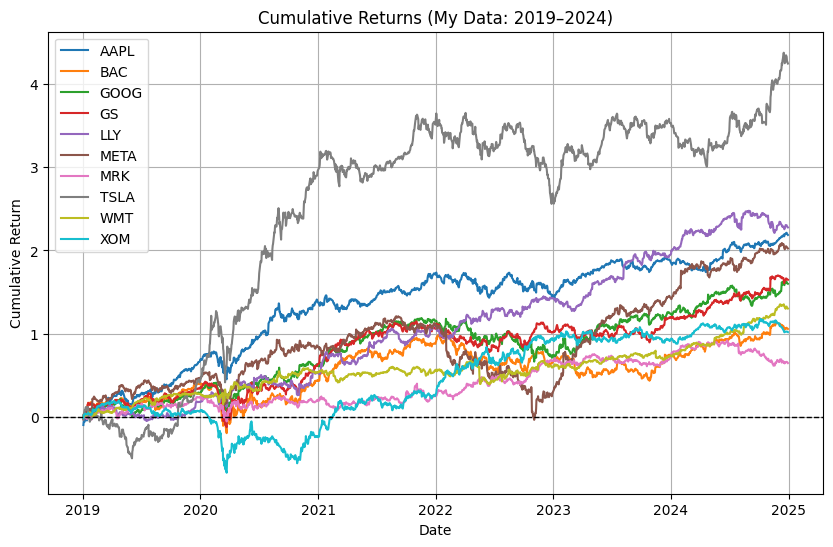

In [ ]:
plot_returns(r_modeling, "Cumulative Returns (My Data: 2019–2024)")

## **PART 1: MEAN-VARIANCE PORTFOLIOS WITH 10 STOCKS**

### **1. Optimal mean-variance portfolio**
**Requirements**
- Weights must sum to 1
- No short-selling

Optimization problem:

$$\max_w w^{\top} r - \frac{1}{2} w^{\top} \Sigma w$$

subject to

$$w^{\top} [1]_N = 1, \quad w \geq [0]_N, $$

in which:
- $w \in R^N$: weight vector
- $r \in R^N$: vector of expected returns from $N$ assets in the portfolio.
- $\Sigma \in R^{N \times N}$: covariance matrix of assets' returns.
- $[1]_N : N \times 1$ all-one vector (vector with all elements as $1$)
- $[0]_N : N \times 1$ all-zero vector (vector with all $0$ elements)

In [ ]:
# Compute the expected return vector and covariance matrix

mu_model = r_modeling.mean()
mu_backtest= r_backtesting.mean()

cov_model = r_modeling.cov()
cov_backtest = r_backtesting.cov()

#print("Expected daily Returns (Modeling):\n", mu_model)
#print("\nCovariance Matrix (Modeling):\n", cov_model)

#print("\nExpected daily Returns (Backtesting):\n", mu_backtest)
#print("\nCovariance Matrix (Backtesting):\n", cov_backtest)

In [ ]:
Sigma = np.array(cov_model)
r_exp = np.array(mu_model)
N = len(r_exp)

# Equality contraints: Aw = b
A = np.ones([N,1])
b = np.array([1])

# Inequality constraints: -w <= 0
G_1 = np.diag([-1] * N)
h_1 = np.zeros(N)

Function `MVO_portfolio` solves a simple  mean-variance portfolio optimization problem.

The solver `cvxpy` solve the optimization problem:

$$\max_w f(w)$$

such that:

$$Aw = b$$

$$G x \leq h$$

for $w \in \mathbb{R}^N$, $A \in \mathbb{R}^{k\times N}$ for $k$ equality constraints, $b\in \mathbb{R}^k$ and $G\in \mathbb{R}^{m \times N}$, $h \in \mathbb{R}^m$ for $m$ inequality constraints.

In [ ]:
import cvxpy as cvx

def MVO_portfolio(Sigma, r_exp, A, b, G, h, alpha=0.5):
    """
    This function solves a simple  mean-variance portfolio optimization problem.
    Inputs:
    - Sigma: Covariance matrix of returns
    - r_exp: Vector of expected returns

    - A: Equality constraint matrix (sum of weights = 1)
    - b: Equality constraint vector (sum of weights = 1)
      => Default Equatlity contraints: Aw = b

    - G: Inequality constraint matrix
    - h: Inequality constraint vector
      => Default Inequality contraints: Gw <= h
    - alpha: Risk aversion parameter (default = 0.5)

    Returns:
    - w_opt: Optimal portfolio weights
    """
    N = len(r_exp)  # Number of assets
    w = cvx.Variable(N)  # Portfolio weights

    # Define the problem
    prob = cvx.Problem(cvx.Maximize((-alpha / 2) * cvx.quad_form(w, Sigma) + r_exp.T @ w),
                        [G @ w <= h, A.T @ w == b])

    # Solve the optimization problem
    prob.solve()

    # Store the optimal portfolio weights
    w_opt = w.value

    return w_opt

- Optimal weights:

In [ ]:
w_opt_1 = MVO_portfolio(Sigma, r_exp, A, b, G_1, h_1, alpha=0.5)
w_series_1 = pd.Series(w_opt_1, index=mu_model.index).apply(lambda x: f"{x:.4f}")
print('Optimal weights of our 10-stock portfolio in Step 1: ', w_series_1)


Optimal weights of our 10-stock portfolio in Step 1:  Ticker
AAPL    -0.0000
BAC     -0.0000
GOOG    -0.0000
GS      -0.0000
LLY     -0.0000
META    -0.0000
MRK     -0.0000
TSLA     1.0000
WMT     -0.0000
XOM     -0.0000
dtype: object


- Mean-Variance portfolio (no short selling) return:

In [ ]:
opt_ptf_ret_1 = np.dot(w_opt_1, r_exp)
print("Expected return optimal porfolio (no short selling): ", f"{opt_ptf_ret_1:.2%}")

Expected return optimal porfolio (no short selling):  0.28%


- Mean-Variance Portfolio (no short selling) Volatility:

In [ ]:
opt_ptf_std_1 = np.sqrt(np.dot(w_opt_1, Sigma.dot(w_opt_1.T)))
print("Expected std. deviation optimal porfolio (no short selling): ", f"{opt_ptf_std_1:.2%}")

Expected std. deviation optimal porfolio (no short selling):  4.06%


### 1.1 Unconstrained Mean-Variance Portfolio

As a small diagnostic example, we also solve the mean-variance problem without the no-short-selling constraint. In this case, the only constraint is that the portfolio weights must sum to one. This helps us see whether the unconstrained model produces negative weights, which correspond to short-selling positions.

In [ ]:
# Unconstrained mean-variance portfolio
# Only the budget constraint is imposed: sum of weights = 1

def MVO_portfolio_budget_only(Sigma, r_exp, A, b, alpha=0.5):
    N = len(r_exp)
    w = cvx.Variable(N)

    objective = cvx.Maximize((-alpha / 2) * cvx.quad_form(w, Sigma) + r_exp.T @ w)
    constraints = [A.T @ w == b]

    prob = cvx.Problem(objective, constraints)
    prob.solve()

    return w.value

w_opt_unconstrained = MVO_portfolio_budget_only(Sigma, r_exp, A, b, alpha=0.5)

w_series_unconstrained = pd.Series(
    w_opt_unconstrained,
    index=mu_model.index
).apply(lambda x: f"{x:.4f}")

print("Optimal weights of the unconstrained mean-variance portfolio:")
print(w_series_unconstrained)

Optimal weights of the unconstrained mean-variance portfolio:
Ticker
AAPL     2.5542
BAC     -4.0574
GOOG    -2.2032
GS       4.0585
LLY      5.8558
META     0.2510
MRK     -7.1263
TSLA     2.2969
WMT     -0.0759
XOM     -0.5536
dtype: object


In [ ]:
# Summary of unconstrained weights

min_weight = np.min(w_opt_unconstrained)
max_weight = np.max(w_opt_unconstrained)
num_negative_weights = np.sum(w_opt_unconstrained < -1e-4)
sum_weights = np.sum(w_opt_unconstrained)

l1_norm_unconstrained = np.sum(np.abs(w_opt_unconstrained))
print(f"L1 norm / total absolute exposure: {l1_norm_unconstrained:.4f}")

print(f"Minimum weight: {min_weight:.4f}")
print(f"Maximum weight: {max_weight:.4f}")
print(f"Number of negative weights: {num_negative_weights}")
print(f"Sum of weights: {sum_weights:.4f}")

L1 norm / total absolute exposure: 29.0329
Minimum weight: -7.1263
Maximum weight: 5.8558
Number of negative weights: 5
Sum of weights: 1.0000


The unconstrained solution gives several negative weights. In this example, five assets receive negative allocations, with the minimum weight equal to -7.1263. This means that the model suggests strong short-selling positions. The maximum weight is also very large, equal to 5.8558, although the total sum of weights is still equal to 1. This illustrates why practical constraints such as \(w_i \geq 0\) are important in portfolio optimization.

### **2. Optimal mean-variance portfolio with box constraints**
**Requirements**
- As above
- No asset represents more than 15% of the portfolio ($w_i \leq 0.15$ for all $i = 1, ..., 10$).

Optimization problem:

$$\max_w w^{\top} r - \frac{1}{2} w^{\top} \Sigma w$$

subject to

$$w^{\top} [1]_N = 1, \quad w \geq [0]_N,  \quad w \leq 0.15 \times [1]_N$$

In [ ]:
# New inequality constraints: including box contraints
G_2 = np.vstack((np.diag([-1] * N), np.diag([1] * N)))
h_2 =  np.hstack((np.zeros(N), 0.15*np.ones(N)))

- Optimal weights (box constrained):

In [ ]:
w_opt_2 = MVO_portfolio(Sigma, r_exp, A, b, G_2, h_2, alpha=0.5)
w_series_2 = pd.Series(w_opt_2, index=mu_model.index).apply(lambda x: f"{x:.4f}")
print('Optimal weights of our 10-stock portfolio (no short selling + box constrained): ', w_series_2)

Optimal weights of our 10-stock portfolio (no short selling + box constrained):  Ticker
AAPL    0.1500
BAC     0.0000
GOOG    0.1500
GS      0.1500
LLY     0.1500
META    0.1500
MRK     0.0000
TSLA    0.1500
WMT     0.1000
XOM     0.0000
dtype: object


- Mean-Variance portfolio (no short selling + box constrained) return:

In [ ]:
opt_ptf_ret_2 = np.dot(w_opt_2, r_exp)
print("Expected return optimal porfolio (no short selling + box constrained): ", f"{opt_ptf_ret_2:.2%}")

Expected return optimal porfolio (no short selling + box constrained):  0.15%


- Mean-Variance Portfolio (no short selling + box constrained) Volatility:

In [ ]:
opt_ptf_std_2 = np.sqrt(np.dot(w_opt_2, Sigma.dot(w_opt_2.T)))
print("Expected std. deviation optimal porfolio (no short selling+ box constrained): ", f"{opt_ptf_std_2:.2%}")

Expected std. deviation optimal porfolio (no short selling+ box constrained):  1.58%


### 2.1 Comparison of Portfolio Concentration

To better understand the effect of the box constraint, we compare the two optimal portfolios using simple concentration measures. In particular, we compute the maximum portfolio weight, the number of assets with positive allocation, and the Herfindahl-Hirschman Index (HHI). A larger HHI indicates that the portfolio is more concentrated.

In [ ]:
# Compare concentration of the two optimal portfolios

def portfolio_summary(w, r_exp, Sigma, model_name):
    """
    Compute simple summary statistics for an optimized portfolio.
    """
    expected_return = np.dot(w, r_exp)
    volatility = np.sqrt(np.dot(w, Sigma.dot(w.T)))
    max_weight = np.max(w)
    num_assets = np.sum(w > 1e-4)
    hhi = np.sum(w**2)

    return {
        "Model": model_name,
        "Expected Return": expected_return,
        "Volatility": volatility,
        "Max Weight": max_weight,
        "Number of Selected Assets": num_assets,
        "HHI": hhi
    }

summary_1 = portfolio_summary(w_opt_1, r_exp, Sigma, "No short-selling")
summary_2 = portfolio_summary(w_opt_2, r_exp, Sigma, "Box-constrained")

comparison_table = pd.DataFrame([summary_1, summary_2])

comparison_table["Expected Return"] = comparison_table["Expected Return"].apply(lambda x: f"{x:.2%}")
comparison_table["Volatility"] = comparison_table["Volatility"].apply(lambda x: f"{x:.2%}")
comparison_table["Max Weight"] = comparison_table["Max Weight"].apply(lambda x: f"{x:.2%}")
comparison_table["HHI"] = comparison_table["HHI"].apply(lambda x: f"{x:.4f}")

comparison_table

,Model,Expected Return,Volatility,Max Weight,Number of Selected Assets,HHI
0,No short-selling,0.28%,4.06%,100.00%,1,1.0000
1,Box-constrained,0.15%,1.58%,15.00%,7,0.1450


### Interpretation of the Comparison

The comparison shows that the no-short-selling portfolio is highly concentrated. In this case, the optimizer allocates all the capital to only one asset, which gives a maximum weight of 100% and an HHI equal to 1. This confirms one of the practical limitations of the basic mean-variance model: even without short-selling, the solution may still be very concentrated.

After adding the box constraint \($w_i \leq 0.15$\), the portfolio becomes more diversified. The maximum weight is limited to 15%, the number of selected assets increases to 7, and the HHI decreases to 0.1450. The expected return is lower, but the volatility also decreases. Therefore, the box constraint makes the portfolio more realistic and more diversified.

### 2.2 Sensitivity to the Upper Bound

In this small extension, we study how the optimal portfolio changes when the upper bound on each asset weight is modified. We compare three cases: 10%, 15%, and 20%. This allows us to see the trade-off between diversification and expected return.

In [ ]:
# Sensitivity analysis for different upper bounds

upper_bounds = [0.10, 0.15, 0.20]
sensitivity_results = []

for ub in upper_bounds:
    G_box = np.vstack((np.diag([-1] * N), np.diag([1] * N)))
    h_box = np.hstack((np.zeros(N), ub * np.ones(N)))

    w_box = MVO_portfolio(Sigma, r_exp, A, b, G_box, h_box, alpha=0.5)

    expected_return = np.dot(w_box, r_exp)
    volatility = np.sqrt(np.dot(w_box, Sigma.dot(w_box.T)))
    max_weight = np.max(w_box)
    num_assets = np.sum(w_box > 1e-4)
    hhi = np.sum(w_box**2)

    sensitivity_results.append({
        "Upper Bound": f"{ub:.0%}",
        "Expected Return": expected_return,
        "Volatility": volatility,
        "Max Weight": max_weight,
        "Number of Selected Assets": num_assets,
        "HHI": hhi
    })

sensitivity_table = pd.DataFrame(sensitivity_results)

sensitivity_table["Expected Return"] = sensitivity_table["Expected Return"].apply(lambda x: f"{x:.2%}")
sensitivity_table["Volatility"] = sensitivity_table["Volatility"].apply(lambda x: f"{x:.2%}")
sensitivity_table["Max Weight"] = sensitivity_table["Max Weight"].apply(lambda x: f"{x:.2%}")
sensitivity_table["HHI"] = sensitivity_table["HHI"].apply(lambda x: f"{x:.4f}")

sensitivity_table

,Upper Bound,Expected Return,Volatility,Max Weight,Number of Selected Assets,HHI
0,10%,0.12%,1.36%,10.00%,10,0.1000
1,15%,0.15%,1.58%,15.00%,7,0.1450
2,20%,0.16%,1.74%,20.00%,5,0.2000


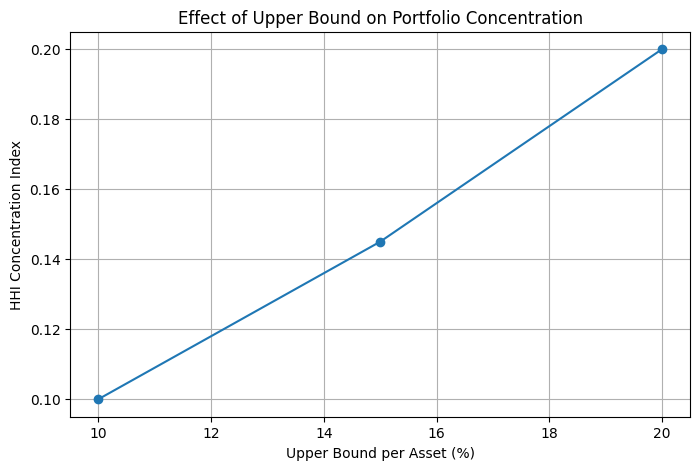

In [ ]:
# Plot concentration as a function of the upper bound

upper_bounds_percent = [10, 15, 20]
hhi_values = [0.1000, 0.1450, 0.2000]

plt.figure(figsize=(8, 5))
plt.plot(upper_bounds_percent, hhi_values, marker='o')

plt.title("Effect of Upper Bound on Portfolio Concentration")
plt.xlabel("Upper Bound per Asset (%)")
plt.ylabel("HHI Concentration Index")
plt.grid(True)
plt.show()

The figure shows that the concentration of the portfolio increases when the upper bound per asset becomes less restrictive. With a 10% upper bound, the HHI is close to 0.10, which indicates a highly diversified allocation across the 10 assets. When the upper bound increases to 15% and 20%, the optimizer has more freedom to allocate larger weights to fewer assets, and the HHI increases. This confirms that box constraints can be used as a practical tool to control portfolio concentration.

## 2.3 Turnover Constraint: Additional Empirical Illustration

To illustrate the role of a turnover constraint, we take the current portfolio $w_0$ to be the equal-weight portfolio. Then we solve a mean-variance problem with no short-selling, the same 15% upper bound, and the additional turnover constraint
$$
\|w-w_0\|_1 \leq \tau.
$$
This shows how the optimizer is forced to stay closer to the current allocation.

In [ ]:
# 2.3 Turnover Constraint: Additional Empirical Illustration

# Convert inputs to numpy arrays
Sigma_np = np.asarray(Sigma)
Sigma_np = (Sigma_np + Sigma_np.T) / 2   # make sure covariance matrix is symmetric
r_exp_np = np.asarray(r_exp).reshape(-1)
N = len(r_exp_np)

# Asset names
try:
    asset_names = list(mu_model.index)
except:
    asset_names = tickers

# Current portfolio before rebalancing: equal-weight portfolio
w0 = np.ones(N) / N

# Turnover limit
tau = 0.30

# Upper bound used in the box-constrained model
upper_bound = 0.15

# Optimization variable
w_turnover = cvx.Variable(N)

# Mean-variance objective
objective = cvx.Maximize(
    r_exp_np @ w_turnover - 0.5 * cvx.quad_form(w_turnover, Sigma_np)
)

# Constraints: budget, no short-selling, upper bound, and turnover control
constraints = [
    cvx.sum(w_turnover) == 1,
    w_turnover >= 0,
    w_turnover <= upper_bound,
    cvx.norm1(w_turnover - w0) <= tau
]

# Solve the problem
prob = cvx.Problem(objective, constraints)
prob.solve()

# Extract solution
w_opt_turnover = np.array(w_turnover.value).flatten()

# Compute summary statistics
turnover_value = np.sum(np.abs(w_opt_turnover - w0))
expected_return_turnover = np.dot(w_opt_turnover, r_exp_np)
volatility_turnover = np.sqrt(np.dot(w_opt_turnover, Sigma_np.dot(w_opt_turnover)))
max_weight_turnover = np.max(w_opt_turnover)
num_assets_turnover = np.sum(w_opt_turnover > 1e-4)
hhi_turnover = np.sum(w_opt_turnover ** 2)

# Summary table
turnover_summary = pd.DataFrame({
    "Quantity": [
        "Expected Return",
        "Volatility",
        "Maximum Weight",
        "Number of Selected Assets",
        "HHI",
        "Turnover ||w - w0||_1",
        "Turnover Limit tau"
    ],
    "Value": [
        f"{expected_return_turnover:.2%}",
        f"{volatility_turnover:.2%}",
        f"{max_weight_turnover:.2%}",
        num_assets_turnover,
        f"{hhi_turnover:.4f}",
        f"{turnover_value:.4f}",
        f"{tau:.2f}"
    ]
})

turnover_summary

,Quantity,Value
0,Expected Return,0.14%
1,Volatility,1.49%
2,Maximum Weight,15.00%
3,Number of Selected Assets,9
4,HHI,0.1200
5,Turnover ||w - w0||_1,0.3000
6,Turnover Limit tau,0.30


In [ ]:
# Portfolio weights and changes relative to the current portfolio

turnover_weights = pd.DataFrame({
    "Asset": asset_names,
    "Current Weight w0": w0,
    "New Weight with Turnover Constraint": w_opt_turnover,
    "Absolute Change": np.abs(w_opt_turnover - w0)
})

turnover_weights["Current Weight w0"] = turnover_weights["Current Weight w0"].apply(lambda x: f"{x:.2%}")
turnover_weights["New Weight with Turnover Constraint"] = turnover_weights["New Weight with Turnover Constraint"].apply(lambda x: f"{x:.2%}")
turnover_weights["Absolute Change"] = turnover_weights["Absolute Change"].apply(lambda x: f"{x:.2%}")

turnover_weights

,Asset,Current Weight w0,New Weight with Turnover Constraint,Absolute Change
0,AAPL,10.00%,15.00%,5.00%
1,BAC,10.00%,5.00%,5.00%
2,GOOG,10.00%,10.00%,0.00%
3,GS,10.00%,10.00%,0.00%
4,LLY,10.00%,15.00%,5.00%
5,META,10.00%,10.00%,0.00%
6,MRK,10.00%,-0.00%,10.00%
7,TSLA,10.00%,15.00%,5.00%
8,WMT,10.00%,10.00%,0.00%
9,XOM,10.00%,10.00%,0.00%


In [ ]:
# Comparison: box-constrained portfolio vs box + turnover constraint

w_box = np.asarray(w_opt_2).reshape(-1)

turnover_box_from_w0 = np.sum(np.abs(w_box - w0))
expected_return_box = np.dot(w_box, r_exp_np)
volatility_box = np.sqrt(np.dot(w_box, Sigma_np.dot(w_box)))
max_weight_box = np.max(w_box)
num_assets_box = np.sum(w_box > 1e-4)
hhi_box = np.sum(w_box ** 2)

comparison_turnover = pd.DataFrame({
    "Model": [
        "Box-constrained",
        "Box + turnover constraint"
    ],
    "Expected Return": [
        f"{expected_return_box:.2%}",
        f"{expected_return_turnover:.2%}"
    ],
    "Volatility": [
        f"{volatility_box:.2%}",
        f"{volatility_turnover:.2%}"
    ],
    "Max Weight": [
        f"{max_weight_box:.2%}",
        f"{max_weight_turnover:.2%}"
    ],
    "Number of Selected Assets": [
        num_assets_box,
        num_assets_turnover
    ],
    "HHI": [
        f"{hhi_box:.4f}",
        f"{hhi_turnover:.4f}"
    ],
    "Turnover from w0": [
        f"{turnover_box_from_w0:.4f}",
        f"{turnover_value:.4f}"
    ]
})

comparison_turnover

,Model,Expected Return,Volatility,Max Weight,Number of Selected Assets,HHI,Turnover from w0
0,Box-constrained,0.15%,1.58%,15.00%,7,0.1450,0.6000
1,Box + turnover constraint,0.14%,1.49%,15.00%,9,0.1200,0.3000


### **3. Compare the efficient frontiers in Step 1 vs Step 2**

In order to compare 2 steps, we write

- A function to find the weight to minimize the portfolio variance given the target return.

  $$\min_w w^{\top} \Sigma w$$

subject to

$$w^{\top} [1]_N = 1, \quad w \geq [0]_N,  \quad w^{\top} r = r_{target}$$
(in case of Section 2, adding the constraints: $w \leq 0.15 \times [1]_N$)

- Note: since the target return is the convex combination of individual asset returns, the target return needs to be in the range of asset returns

- Then for a range of target return, run the function to minimize the variance and get the range of optimal portfolios' equivalent volatilites.

In [ ]:
def MVO_target_return(Sigma, r_exp, target_return, A, b, G, h):

    N = len(r_exp)
    w = cvx.Variable(N)

    prob = cvx.Problem(cvx.Minimize(cvx.quad_form(w, Sigma)),
                        [G @ w <= h, A.T @ w == b, r_exp.T @ w == target_return])

    prob.solve()

    if prob.status == cvx.OPTIMAL:# Check if the problem was solved successfully
        w_opt = w.value
        portfolio_risk = np.sqrt(w_opt.T @ Sigma @ w_opt)
        return portfolio_risk
    else:
        return np.nan


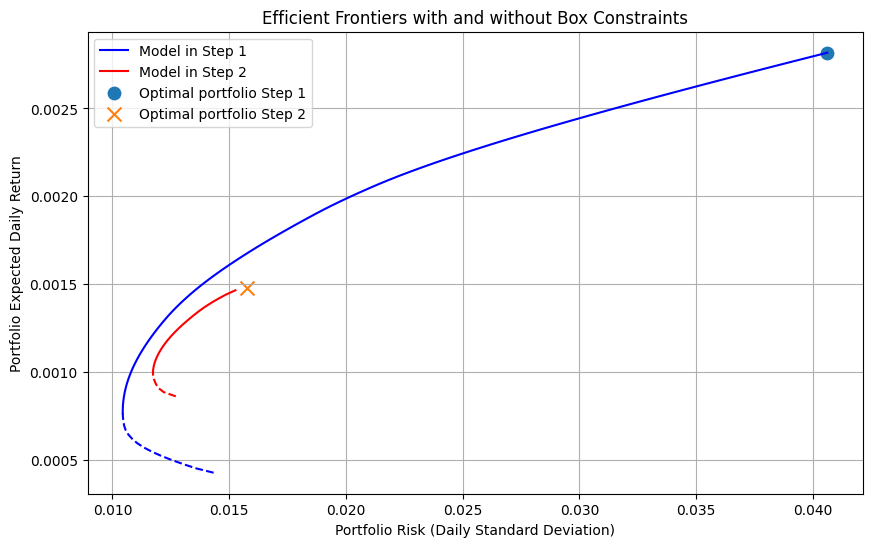

In [ ]:
min_return = np.min(r_exp)
max_return = np.max(r_exp)
target_returns = np.linspace(min_return, max_return, 100)

portf_risks_1 = [MVO_target_return(Sigma, r_exp, r, A, b, G_1, h_1) for r in target_returns]
portf_risks_2 = [MVO_target_return(Sigma, r_exp, r, A, b, G_2, h_2) for r in target_returns]

portf_risks_1 = np.array(portf_risks_1)
portf_risks_2 = np.array(portf_risks_2)

# Remove NaN
valid_1 = ~np.isnan(portf_risks_1)
valid_2 = ~np.isnan(portf_risks_2)

target_returns_1 = target_returns[valid_1]
portf_risks_1 = portf_risks_1[valid_1]

target_returns_2 = target_returns[valid_2]
portf_risks_2 = portf_risks_2[valid_2]

# Secret to plot the nice graph :))
min_var_idx_1 = np.argmin(portf_risks_1)
min_var_idx_2 = np.argmin(portf_risks_2)

# Plot efficient frontier with dashed inefficient parts
plt.figure(figsize=(10, 6))

plt.plot(portf_risks_1[min_var_idx_1:], target_returns_1[min_var_idx_1:], label="Model in Step 1", color='b')
plt.plot(portf_risks_1[:min_var_idx_1+1], target_returns_1[:min_var_idx_1+1], linestyle='dashed', color='b')

plt.plot(portf_risks_2[min_var_idx_2:], target_returns_2[min_var_idx_2:], label="Model in Step 2", color='r')
plt.plot(portf_risks_2[:min_var_idx_2+1], target_returns_2[:min_var_idx_2+1], linestyle='dashed', color='r')

plt.scatter(opt_ptf_std_1, opt_ptf_ret_1, marker='o', s=80, label="Optimal portfolio Step 1")
plt.scatter(opt_ptf_std_2, opt_ptf_ret_2, marker='x', s=100, label="Optimal portfolio Step 2")

plt.title("Efficient Frontiers with and without Box Constraints")
plt.xlabel("Portfolio Risk (Daily Standard Deviation)")
plt.ylabel("Portfolio Expected Daily Return")
plt.grid(True)
plt.legend()
plt.show()

## 4. Backtesting the Portfolio Performance

- Now we have 2 weights for 2 optimimal portfolios: `w_opt_1` and `w_opt_2`.

- We now evaluate the optimized portfolios on the out-of-sample backtesting period using daily returns.

- We compare the two optimized portfolios with the equal-weight benchmark.

- The benchmark portfolio to compare is the equal weight portfolio ($w_1 = ... = w_N = \frac{1}{N}$).

First, let's see how individual stock behave during this backtesting period:

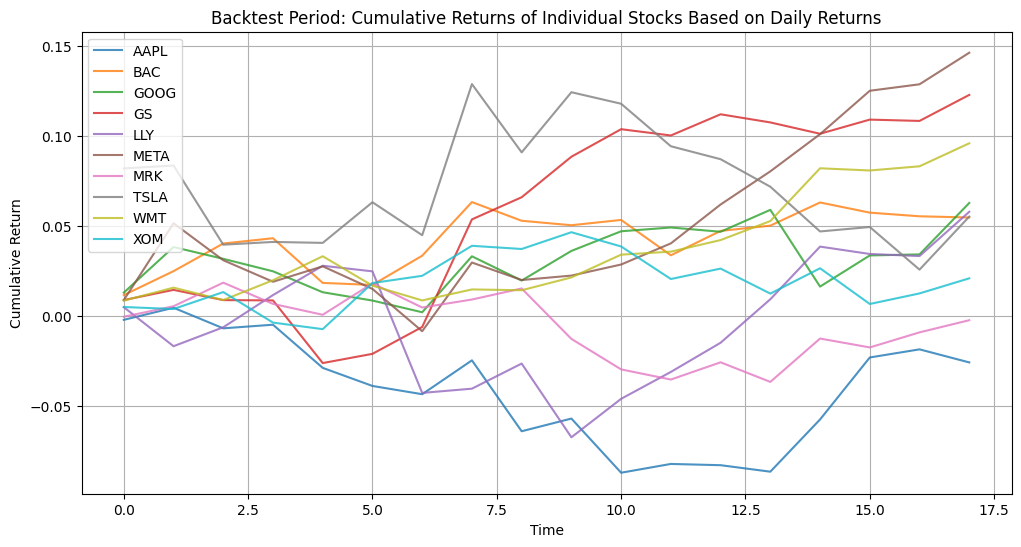

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

r_backtest_np = r_backtesting.to_numpy() if hasattr(r_backtesting, "to_numpy") else np.array(r_backtesting)

cumulative_stocks = np.cumprod(1 + r_backtest_np, axis=0) - 1

stock_names = r_backtesting.columns if hasattr(r_backtesting, "columns") else [f"Stock {i+1}" for i in range(N)]

plt.figure(figsize=(12, 6))
for i in range(N):
    plt.plot(cumulative_stocks[:, i], alpha=0.8, label=stock_names[i])

plt.title("Backtest Period: Cumulative Returns of Individual Stocks Based on Daily Returns")
plt.xlabel("Time")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()


Now is the performance of our portfolios (vs benchmark):

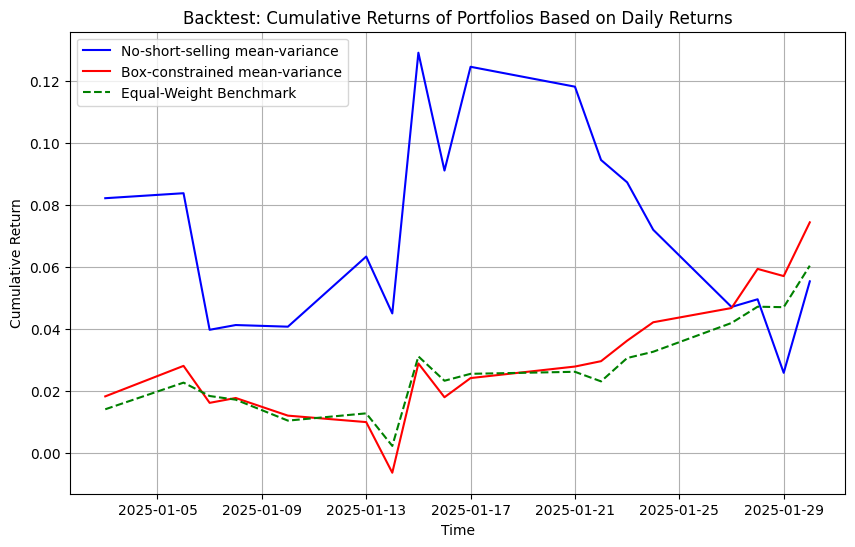

In [ ]:
# Optimal portfolio returns
r_port_1 = r_backtesting @ w_opt_1
r_port_2 = r_backtesting @ w_opt_2

# Equal-weight benchmark portfolio
N = r_backtesting.shape[1]
w_equal = np.ones(N) / N
r_benchmark = r_backtesting @ w_equal

# Cumulative returns
cumulative_ret_1 = np.cumprod(1 + r_port_1) - 1
cumulative_ret_2 = np.cumprod(1 + r_port_2) - 1
cumulative_benchmark = np.cumprod(1 + r_benchmark) - 1

# Plot
plt.figure(figsize=(10, 6))
plt.plot(cumulative_ret_1, label= "No-short-selling mean-variance", color='b')
plt.plot(cumulative_ret_2, label= "Box-constrained mean-variance", color='r')
plt.plot(cumulative_benchmark, label="Equal-Weight Benchmark", linestyle='dashed', color='g')

plt.title("Backtest: Cumulative Returns of Portfolios Based on Daily Returns")
plt.xlabel("Time")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.savefig("backtest_cumulative_returns.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation of the Backtest

The backtest compares the two optimized portfolios with the equal-weight benchmark during the out-of-sample period, using daily returns. The no-short-selling portfolio shows larger fluctuations and a weaker final cumulative return. This is consistent with the previous concentration analysis, where this portfolio allocated all capital to only one asset.

In contrast, the box-constrained portfolio performs more smoothly and achieves a higher final cumulative return than the no-short-selling portfolio. It also stays close to, and slightly above, the equal-weight benchmark. This suggests that adding the upper-bound constraint improves diversification and makes the optimized portfolio more robust during the backtesting period.

In [ ]:
# Backtest performance summary based on daily returns

def backtest_summary(returns, name):
    total_return = np.prod(1 + returns) - 1
    daily_mean_return = np.mean(returns)
    daily_volatility = np.std(returns)
    daily_sharpe_ratio = daily_mean_return / daily_volatility if daily_volatility != 0 else np.nan

    cumulative = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(cumulative)
    drawdown = cumulative / running_max - 1
    max_drawdown = np.min(drawdown)

    return {
        "Strategy": name,
        "Total Return": total_return,
        "Daily Mean Return": daily_mean_return,
        "Daily Volatility": daily_volatility,
        "Daily Sharpe Ratio": daily_sharpe_ratio,
        "Max Drawdown": max_drawdown
    }

backtest_results = [
    backtest_summary(r_port_1, "No-short-selling mean-variance"),
    backtest_summary(r_port_2, "Box-constrained mean-variance"),
    backtest_summary(r_benchmark, "Equal-Weight Benchmark")
]

backtest_table = pd.DataFrame(backtest_results)

backtest_table["Total Return"] = backtest_table["Total Return"].apply(lambda x: f"{x:.2%}")
backtest_table["Daily Mean Return"] = backtest_table["Daily Mean Return"].apply(lambda x: f"{x:.2%}")
backtest_table["Daily Volatility"] = backtest_table["Daily Volatility"].apply(lambda x: f"{x:.2%}")
backtest_table["Daily Sharpe Ratio"] = backtest_table["Daily Sharpe Ratio"].apply(lambda x: f"{x:.2f}")
backtest_table["Max Drawdown"] = backtest_table["Max Drawdown"].apply(lambda x: f"{x:.2%}")

backtest_table

,Strategy,Total Return,Daily Mean Return,Daily Volatility,Daily Sharpe Ratio,Max Drawdown
0,No-short-selling mean-variance,5.54%,0.35%,3.34%,0.11,-9.14%
1,Box-constrained mean-variance,7.44%,0.41%,1.18%,0.34,-3.35%
2,Equal-Weight Benchmark,6.04%,0.33%,0.91%,0.36,-1.99%


### Interpretation of the Backtest Summary

The backtest summary confirms the visual result from the cumulative return plot. The no-short-selling portfolio has a positive total return, but it also has the highest daily volatility and the largest maximum drawdown. This is consistent with its high concentration in one asset.

The box-constrained portfolio achieves the highest total return over the backtesting period. It also has much lower volatility and a smaller drawdown than the no-short-selling portfolio. Compared with the equal-weight benchmark, the box-constrained portfolio has a higher total return, although the benchmark has a slightly higher daily Sharpe ratio and lower drawdown.

Overall, the results suggest that the box constraint improves the practical behavior of the mean-variance portfolio. It reduces concentration risk and gives a more stable out-of-sample performance.

In [ ]:
print(r_modeling.index.min(), r_modeling.index.max())
print(r_backtesting.index.min(), r_backtesting.index.max())

2019-01-03 00:00:00 2024-12-30 00:00:00
2025-01-03 00:00:00 2025-01-30 00:00:00
